# Hatespeech Classification Project

## Phase 1

In [4]:
%pip install pandas seaborn matplotlib wordcloud scikit-learn spacy click

Note: you may need to restart the kernel to use updated packages.


In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("project1_train.csv")

## Phase 1: Dataset

### Task 1: Data exploration and pre-processing

**Data Exploration**

It is not about basic statistics. More importantly, it’s essential to
understand the data, especially from the task point of view. The exploration should at
least answer the following questions: 
- Is the dataset balanced or imbalanced? 
- Is the text varied in length, and how does longer text correlate with certain labels? 
- What are the top-k words (or phrases) in hate speech vs non-hate speech? 
- A related important aspect is the context. “Hate” might be a top distinguishing word for hate speech. But “I hate this weather” is not hate speech. 

On top of these, you are encouraged to explore more.

1) Is the dataset balanced?

In [6]:
df['label_name'] = df['label'].map({
    0: 'Non-Hate Speech',
    1: 'Hate Speech'
})

print(df['label_name'].value_counts())

label_name
Hate Speech        816
Non-Hate Speech    798
Name: count, dtype: int64


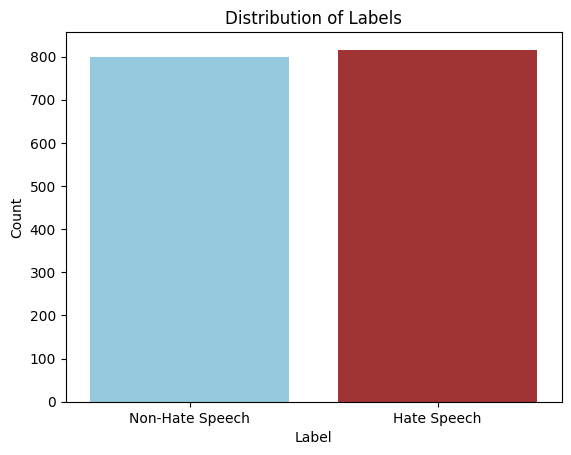

In [7]:
ax = sns.countplot(
    x='label_name',
    hue='label_name',
    data=df,
    palette=['skyblue', 'firebrick'],
    legend=False
)

plt.title('Distribution of Labels')
plt.xlabel('Label')
plt.ylabel('Count')
plt.show()

2) Is the text varied in length, and how does longer text correlate with certain labels? 

In [8]:
df['comment_length'] = df['text'].apply(len)



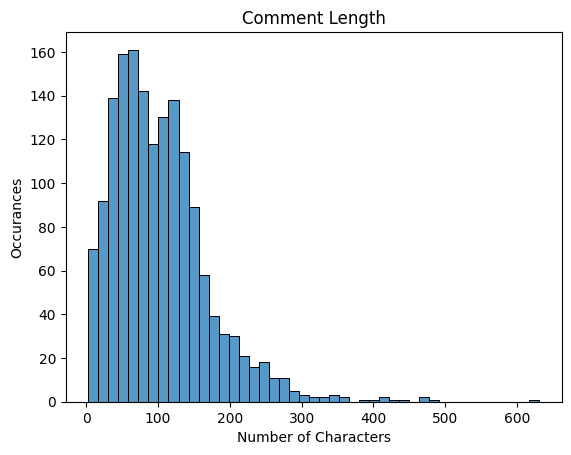

In [9]:
ax = sns.histplot(df['comment_length'])

plt.title('Comment Length')
plt.xlabel('Number of Characters')
plt.ylabel('Occurances')
plt.show()


In [10]:
df.groupby('label_name')['comment_length'].agg(['mean', 'median', 'std', 'count'])

,mean,median,std,count
label_name,,,,
Hate Speech,119.367647,112.0,64.178143,816
Non-Hate Speech,85.411028,66.0,67.940830,798


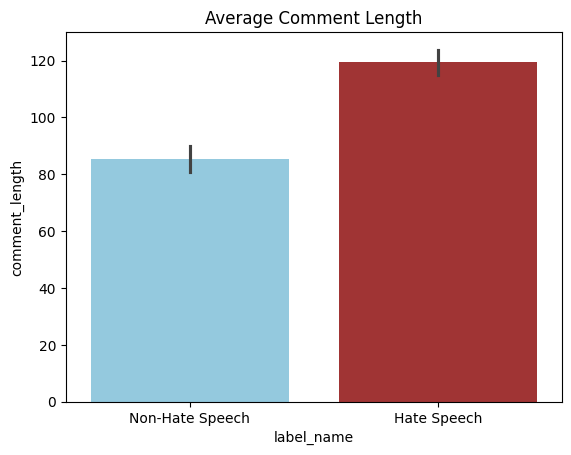

In [11]:
sns.barplot(
    data=df, 
    x='label_name', 
    y='comment_length',
    hue='label_name',
    palette=['skyblue', 'firebrick']
    )

plt.title('Average Comment Length')
plt.show()

3) What are the top-k words (or phrases) in hate speech vs non-hate speech? 

*This section includes a lot of the preprocessing we'll need later*

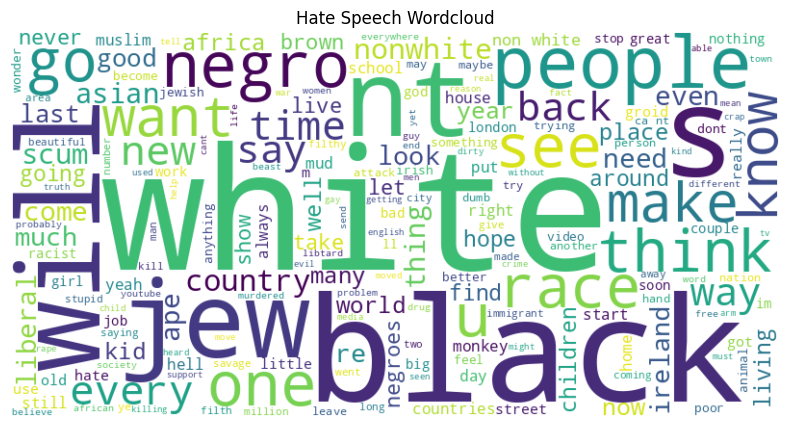

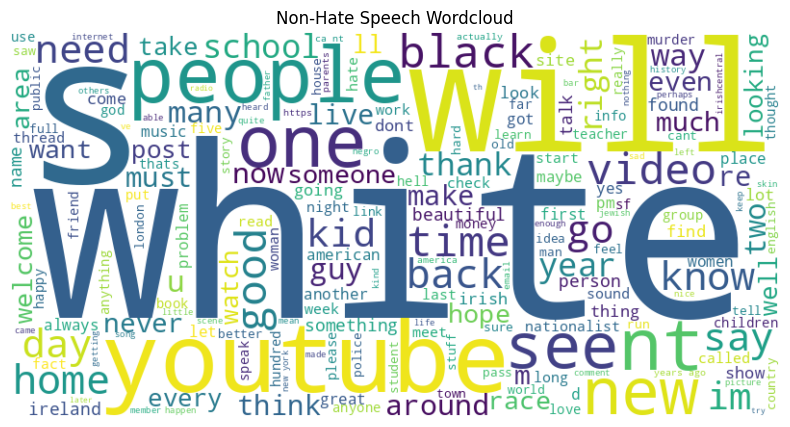

In [12]:
import re
import matplotlib.pyplot as plt
from wordcloud import WordCloud, STOPWORDS

###############
# I cleaned the text below in the generate_wordcloud function, but I wanted a full new column in the df as well.
def clean_text(text):

    text = text.lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"#", "", text)
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    return text

#  Creating new column 'clean_text' with the above rules
df['clean_text'] = df['text'].apply(clean_text)
##############

# function to generate word clouds
def generate_wordcloud(text_series, title):
    text = ' '.join(text_series.astype(str).tolist())

    # clean
    text = re.sub(r'[^A-Za-z\s]', '', text)
    text = text.lower()

    # remove stopwords
    stopwords = set(STOPWORDS)
    text = ' '.join(word for word in text.split() if word not in stopwords)

    # generate wordcloud
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

    # plot
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(title)
    plt.show()

# Generating the separate df's
hate_df = df[df['label_name'] == 'Hate Speech']
nonhate_df = df[df['label_name'] == 'Non-Hate Speech']

generate_wordcloud(hate_df['text'], "Hate Speech Wordcloud")

generate_wordcloud(nonhate_df['text'], "Non-Hate Speech Wordcloud")

Wordclouds are pretty and fun, but we also need to know what words are most distinctive for each label/class.

Below we'll use TD-IDF (Term Frequency - Inverse Document Frequency) to compare each class's most distinctive words.

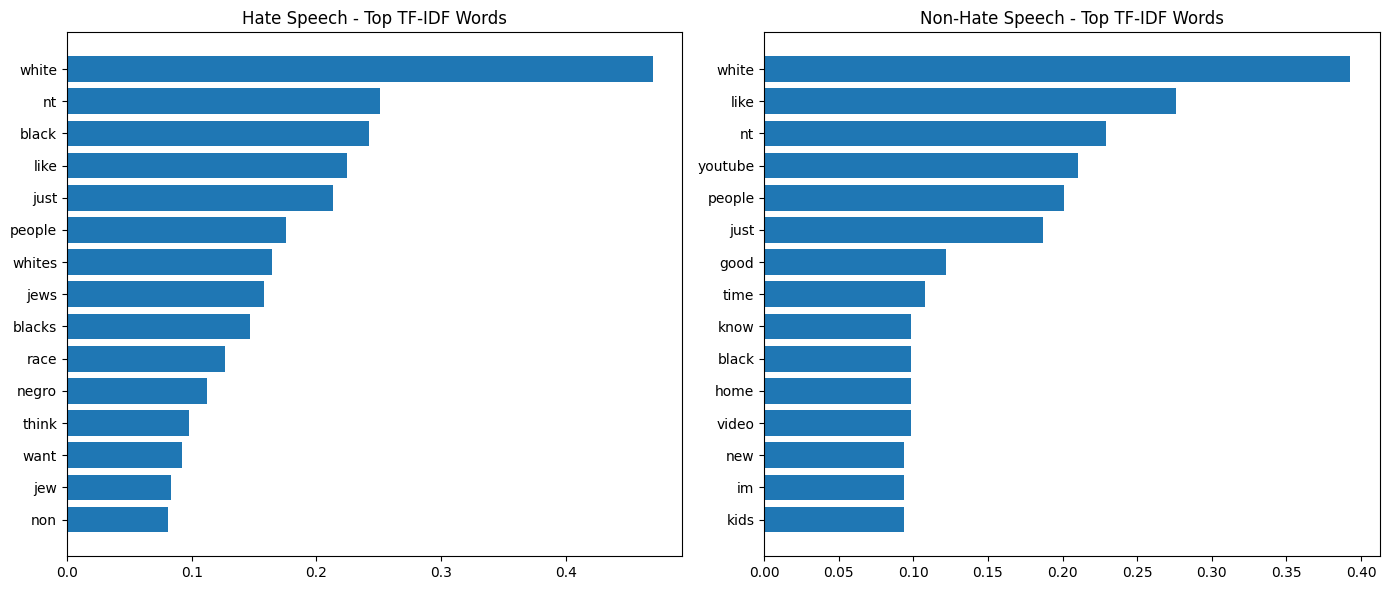

In [13]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Preparing text
hate_text = ' '.join(hate_df['clean_text'].astype(str))
nonhate_text = ' '.join(nonhate_df['clean_text'].astype(str))

corpus = [hate_text, nonhate_text]

labels = ['Hate Speech', 'Non-Hate Speech']

# TF-IDF Vectorizer
vectorizer = TfidfVectorizer(stop_words='english', max_features=5000)

tfidf = vectorizer.fit_transform(corpus)

feature_names = vectorizer.get_feature_names_out()

#top words per class (change n for more or less words)
def get_top_words(row, n=15):
    row_data = row.toarray().flatten()
    top_indices = row_data.argsort()[-n:][::-1]
    return [(feature_names[i], row_data[i]) for i in top_indices]

hate_top = get_top_words(tfidf[0])
nonhate_top = get_top_words(tfidf[1])

# function to plot
def plot_tfidf(words, title, ax):
    words, scores = zip(*words)
    ax.barh(words[::-1], scores[::-1])
    ax.set_title(title)

#side by side comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

plot_tfidf(hate_top, "Hate Speech - Top TF-IDF Words", axes[0])
plot_tfidf(nonhate_top, "Non-Hate Speech - Top TF-IDF Words", axes[1])

plt.tight_layout()
plt.show()

At a Glance:
- Interestingly, we see 'white' used in both as their highest scoring TD_IDF words 

### Lemmatizing

In [14]:
!python -m spacy download en_core_web_sm
import spacy

nlp = spacy.load("en_core_web_sm")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 32.1 MB/s  0:00:00 eta 0:00:01
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


In [15]:
def lemmatize_text(text):
    doc = nlp(text)
    return " ".join([token.lemma_ for token in doc])

df['clean_text'] = df['clean_text'].apply(lemmatize_text)

## Models

In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

x = df["clean_text"]
y = df["label"]

# converting to numbers
vectorizer = TfidfVectorizer()

x_vec = vectorizer.fit_transform(x)

x_train, x_test, y_train, y_test = train_test_split(
    x_vec, y, test_size=0.2, random_state=89
)

# Best Lambda for Regression Model
lambdas = [0.0001, 0.001, 0.01, 0.1, 1, 10]

best_lambda = None
best_accuracy = 0
best_model = None

print("Best λ - Regression Results")
print("---------------------------")

for lam in lambdas:

    C = 1 / lam

    model = LogisticRegression(C=C, max_iter=1000)

    model.fit(x_train, y_train)

    y_pred = model.predict(x_test)

    accuracy = accuracy_score(y_test, y_pred)

    print(f"λ = {lam:<7} Accuracy = {accuracy:.4f}")

    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_lambda = lam
        best_model = model

print("\nBest λ:", best_lambda)
print("Best Accuracy:", round(best_accuracy, 4))

model_1 = LogisticRegression(C=best_lambda)
model_1.fit(x_train, y_train)

# Predictions
y_pred_1 = model_1.predict(x_test)

#Evaluations
accuracy_1 = accuracy_score(y_test, y_pred_1)
precision_1 = precision_score(y_test, y_pred_1)
recall_1 = recall_score(y_test, y_pred_1)
f1_1 = f1_score(y_test, y_pred_1)

print("\nRegression Model Evaluations")
print("----------------------------")
print(f"Accuracy: {accuracy_1: .2f}")
print(f"Precision: {precision_1: .2f}")
print(f"Recall: {recall_1: .2f}")
print(f"F1 Score: {f1_1: .2f}")


from sklearn.naive_bayes import MultinomialNB

# Naive Bayes Model
model_2 = MultinomialNB()
model_2.fit(x_train, y_train)

# Predictions
y_pred_2 = model_2.predict(x_test)

#Evaluations
accuracy_2 = accuracy_score(y_test, y_pred_2)
precision_2 = precision_score(y_test, y_pred_2)
recall_2 = recall_score(y_test, y_pred_2)
f1_2 = f1_score(y_test, y_pred_2)

print("\n")
print("Naive Bayes Model Evaluations")
print("-----------------------------")
print(f"Accuracy: {accuracy_2: .2f}")
print(f"Precision: {precision_2: .2f}")
print(f"Recall: {recall_2: .2f}")
print(f"F1 Score: {f1_2: .2f}")



Best λ - Regression Results
---------------------------
λ = 0.0001  Accuracy = 0.7399
λ = 0.001   Accuracy = 0.7523
λ = 0.01    Accuracy = 0.7461
λ = 0.1     Accuracy = 0.7430
λ = 1       Accuracy = 0.7554
λ = 10      Accuracy = 0.7276

Best λ: 1
Best Accuracy: 0.7554

Regression Model Evaluations
----------------------------
Accuracy:  0.76
Precision:  0.74
Recall:  0.76
F1 Score:  0.75


Naive Bayes Model Evaluations
-----------------------------
Accuracy:  0.71
Precision:  0.64
Recall:  0.92
F1 Score:  0.76


## Phase 2

### LLM Based Predictive Model

In [83]:
%pip install google-generativeai openai

94975.92s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


Note: you may need to restart the kernel to use updated packages.


## Gemini Configuration

In order to run this on your end, you'll need to input your own Gemini API key below and expand the Gemini sections to run them.

In [ ]:
import google.generativeai as genai

genai.configure(api_key="YOUR API KEY HERE") # Your API key goes here!

model = genai.GenerativeModel("gemini-2.5-flash")

Below is my personal llama.cpp server running a Gemma4 model. 

You will not be able to access this but it solves the free tier issue with Gemini for me.

In [109]:
from openai import OpenAI

client = OpenAI(base_url="http://192.168.1.21:8080/v1", api_key="none")

def call_local_llama(prompt):
    response = client.chat.completions.create(
        model="gemma4-e2b",
        messages=[{"role": "user", "content": prompt}],
    )
    return response.choices[0].message.content

# Baseline Prompt

See report for further details

In [ ]:
# change these to change which rows of text the LLM is classifying (for Gemini only)
x = 5
y = 9

Gemini Baseline
------

In [ ]:
predictions = []

for text in df["clean_text"].loc[x:y]:

    prompt = f"""
    Classify the following text:
    {text}

    Return ONLY:
    - Return only one character.
    - Return 1 if the text is hate speech.
    - Return 0 if the text is not hate speech.
    - Do not explain your answer.
    - Do not output any words.
    - Must be in integer format

    """

    response = model.generate_content(prompt)
    # response = call_local_llama(prompt)

    response_text = response.text.strip()
    # response_text = response

    if "1" in response_text:
        prediction = 1
    elif "0" in response_text:
        prediction = 0
    else:
        prediction = -1

    predictions.append(prediction)



Accuracy of Gemini:

In [108]:
from sklearn.metrics import accuracy_score

In [ ]:
accuracy = accuracy_score(
    df["label"],
    predictions
)

print(f"{accuracy*100}%")

In [103]:
print(df["label"].iloc[x:y])

14    0
Name: label, dtype: int64


In [104]:
for label in df["label"][x:y]:
    print(label)


0


OpenAI Baseline
------

In [138]:
predictions = []

for text in df["clean_text"]:

    prompt = f"""
    Classify the following text:
    {text}

    Return ONLY:
    - Return only one character.
    - Return 1 if the text is hate speech.
    - Return 0 if the text is not hate speech.
    - Do not explain your answer.
    - Do not output any words.
    - Must be in integer format

    """

    # response = model.generate_content(prompt)
    response = call_local_llama(prompt)

    # response_text = response.text.strip()
    response_text = response

    if "1" in response_text:
        prediction = 1
    elif "0" in response_text:
        prediction = 0
    else:
        prediction = -1

    predictions.append(prediction)

Accuracy of OpenAI

In [114]:
accuracy = accuracy_score(
    df["label"],
    predictions
)

print(f"{accuracy*100:.2f}%")

73.85%


# Error Analysis - Baseline

In [132]:
# Results DF w Prediction and Actual
results_df = df.copy()

results_df["prediction"] = predictions

results_df["correct"] = (
    results_df["label"] == results_df["prediction"]
)

# Error Counting
num_errors = (~results_df["correct"]).sum()

print(f"Misclassified Examples: {num_errors}")

#Error Rate
error_rate = num_errors / len(results_df)

print(f"Error Rate: {error_rate*100:.2f}%")

Misclassified Examples: 369
Error Rate: 22.86%


### View the mistakes

In [ ]:
errors = results_df[
    results_df["label"] != results_df["prediction"]
]

print("Errors:\n")
print(errors.head(20))

# False Positives (predicted hatespeech, wasn't hatespeech)
false_positives = results_df[
    (results_df["label"] == 0) &
    (results_df["prediction"] == 1)
]

print("\nFalse Positives:\n")
print(false_positives.head(20))

# False Negatives (predicted non-hatespeech, was hatespeech)
false_negatives = results_df[
    (results_df["label"] == 1) &
    (results_df["prediction"] == 0)
]

print("\nFalse Negatives:\n")
print(false_negatives.head(20))

Errors:

                                                 text  label       label_name  \
6   God knows what would come out of Africa if onl...      1      Hate Speech   
8   We are trying to get people in every White nat...      0  Non-Hate Speech   
11  I watch fights on gay parade in budapest toget...      1      Hate Speech   
13  We have a little piece of legislation called t...      1      Hate Speech   
19  It is hard to say what is going to happen howe...      0  Non-Hate Speech   
22  Here's a site that compiles news articles of w...      0  Non-Hate Speech   
23  I also , unfortuantely , spent 7-8th grade in ...      1      Hate Speech   
25  I was basically a babysitter , and the apes we...      1      Hate Speech   
39  Their gods often had pale skin and blue eyes b...      1      Hate Speech   
41  As usual the magic negro opens his mouth and l...      1      Hate Speech   
44  The majority of the people in these photos are...      1      Hate Speech   
45            well,

## Improved Baseline - Few Shot Learning

Gemini w Few Shot
------

In [ ]:
predictions = []

for text in df["clean_text"][x:y]:

    prompt = f"""
    Examples:

    Text - I hate this weather.
    Label - 0

    Text - All people of a certain type are gross
    Label - 1
    
    Classify the following text:
    {text}

    Return ONLY:
    - Return only one character.
    - Return 1 if the text is hate speech.
    - Return 0 if the text is not hate speech.
    - Do not explain your answer.
    - Do not output any words.
    """

    response = model.generate_content(prompt)
    # response = call_local_llama(prompt)

    response_text = response.text.strip()
    # response_text = response

    if "1" in response_text:
        prediction = 1
    elif "0" in response_text:
        prediction = 0
    else:
        prediction = -1

    predictions.append(prediction)



Accuracy of Gemini with Few Shot

In [ ]:
accuracy = accuracy_score(
    df["label"],
    predictions
)

print(f"{accuracy*100}%")

OpenAI w Few Shot
------

In [134]:
predictions = []

for text in df["clean_text"]:

    prompt = f"""
    Examples:

    Text - I hate this weather.
    Label - 0

    Text - All people of a certain type are gross
    Label - 1
    
    Classify the following text:
    {text}

    Return ONLY:
    - Return only one character.
    - Return 1 if the text is hate speech.
    - Return 0 if the text is not hate speech.
    - Do not explain your answer.
    - Do not output any words.
    """

    # response = model.generate_content(prompt)
    response = call_local_llama(prompt)

    # response_text = response.text.strip()
    response_text = response

    if "1" in response_text:
        prediction = 1
    elif "0" in response_text:
        prediction = 0
    else:
        prediction = -1

    predictions.append(prediction)



Accuracy of OpenAI with Few Shot

In [118]:
accuracy = accuracy_score(
    df["label"],
    predictions
)

print(f"{accuracy*100:.2f}%")

76.77%


# Error Analysis - Few Shot Learning

In [135]:
# Results DF w Prediction and Actual
results_df = df.copy()

results_df["prediction"] = predictions

results_df["correct"] = (
    results_df["label"] == results_df["prediction"]
)

# Error Counting
num_errors = (~results_df["correct"]).sum()

print(f"Misclassified Examples: {num_errors}")

#Error Rate
error_rate = num_errors / len(results_df)

print(f"Error Rate: {error_rate*100:.2f}%")

Misclassified Examples: 370
Error Rate: 22.92%


## View the mistakes

In [136]:
errors = results_df[
    results_df["label"] != results_df["prediction"]
]

print("Errors:\n")
print(errors.head(20))

# False Positives
false_positives = results_df[
    (results_df["label"] == 0) &
    (results_df["prediction"] == 1)
]

print("\nFalse Positives:\n")
print(false_positives.head(20))

# False Negatives
false_negatives = results_df[
    (results_df["label"] == 1) &
    (results_df["prediction"] == 0)
]

print("\nFalse Negatives:\n")
print(false_negatives.head(20))

Errors:

                                                 text  label       label_name  \
6   God knows what would come out of Africa if onl...      1      Hate Speech   
8   We are trying to get people in every White nat...      0  Non-Hate Speech   
13  We have a little piece of legislation called t...      1      Hate Speech   
19  It is hard to say what is going to happen howe...      0  Non-Hate Speech   
22  Here's a site that compiles news articles of w...      0  Non-Hate Speech   
23  I also , unfortuantely , spent 7-8th grade in ...      1      Hate Speech   
25  I was basically a babysitter , and the apes we...      1      Hate Speech   
39  Their gods often had pale skin and blue eyes b...      1      Hate Speech   
41  As usual the magic negro opens his mouth and l...      1      Hate Speech   
44  The majority of the people in these photos are...      1      Hate Speech   
45            well, the liberals would go ape crazy .      1      Hate Speech   
47  It would be gre

# Improved Baseline - Structured Reasoning

Gemini w SR
----

In [ ]:
predictions = []

for text in df["clean_text"][x:y]:

    prompt = f"""
    Think Step by Step.

    Determine:

    Step 1:
    Is there a target group?

    Step 2:
    Is the statement attacking the group?

    Step 3:
    Is the attack based on racial or religious identity?

    If all are true:
    Return 1

    Otherwise:
    Return 0

    Text:
    {text}

    """

    response = model.generate_content(prompt)
    # response = call_local_llama(prompt)

    response_text = response.text.strip()
    # response_text = response

    if "1" in response_text:
        prediction = 1
    elif "0" in response_text:
        prediction = 0
    else:
        prediction = -1

    predictions.append(prediction)



Accuracy of Gemini w Structured Reasoning

In [ ]:
accuracy = accuracy_score(
    df["label"],
    predictions
)

print(f"{accuracy*100}%")

OpenAI w SR
---

In [119]:
predictions = []

for text in df["clean_text"]:

    prompt = f"""
    Think Step by Step.

    Determine:

    Step 1:
    Is there a target group?

    Step 2:
    Is the statement attacking the group?

    Step 3:
    Is the attack based on racial or religious identity?

    If all are true:
    Return 1

    Otherwise:
    Return 0

    Text:
    {text}

    """

    # response = model.generate_content(prompt)
    response = call_local_llama(prompt)

    # response_text = response.text.strip()
    response_text = response

    if "1" in response_text:
        prediction = 1
    elif "0" in response_text:
        prediction = 0
    else:
        prediction = -1

    predictions.append(prediction)



OpenAI w SR Accuracy

In [120]:
accuracy = accuracy_score(
    df["label"],
    predictions
)

print(f"{accuracy*100:.2f}%")

50.56%


# Error Analysis - Structured Reasoning

In [ ]:
# Results DF w Prediction and Actual
results_df = df.copy()

results_df["prediction"] = predictions

results_df["correct"] = (
    results_df["label"] == results_df["prediction"]
)

# Error Counting
num_errors = (~results_df["correct"]).sum()

print(f"Misclassified Examples: {num_errors}")

#Error Rate
error_rate = num_errors / len(results_df)

print(f"Error Rate: {error_rate*100:.2f}%")

## View the mistakes

In [130]:
errors = results_df[
    results_df["label"] != results_df["prediction"]
]

print("Errors:\n")
print(errors.head(20))

# False Positives
false_positives = results_df[
    (results_df["label"] == 0) &
    (results_df["prediction"] == 1)
]

print("\nFalse Positives:\n")
print(false_positives.head(20))

# False Negatives
false_negatives = results_df[
    (results_df["label"] == 1) &
    (results_df["prediction"] == 0)
]

print("\nFalse Negatives:\n")
print(false_negatives.head(20))

Errors:

                                                 text  label       label_name  \
0   In order to help increase the booklets downloa...      0  Non-Hate Speech   
3                Booklet updated on Dec. 9th , 2013 .      0  Non-Hate Speech   
4   Thank you in advance. : ) Download the youtube...      0  Non-Hate Speech   
8   We are trying to get people in every White nat...      0  Non-Hate Speech   
14           You are welcome to grab on if you like !      0  Non-Hate Speech   
16         I have no idea of how many might be here .      0  Non-Hate Speech   
17  Only if they get their collective heads out of...      0  Non-Hate Speech   
18  Our brothers & sisters in SA must stand their ...      0  Non-Hate Speech   
19  It is hard to say what is going to happen howe...      0  Non-Hate Speech   
21  I'm looking to study at a college in South Afr...      0  Non-Hate Speech   
22  Here's a site that compiles news articles of w...      0  Non-Hate Speech   
28          I think